<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kesepuluh/blob/main/TUGAS_MG_10_OPERASI_MORFOLOGI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 2 gambar:
1. Citra A (teks OCR)
2. Citra B (objek counting)


Saving Citra B Objek overlapping koin.jpeg to Citra B Objek overlapping koin.jpeg
Saving Citra A Teks Dokumen dengan noise.jpeg to Citra A Teks Dokumen dengan noise.jpeg


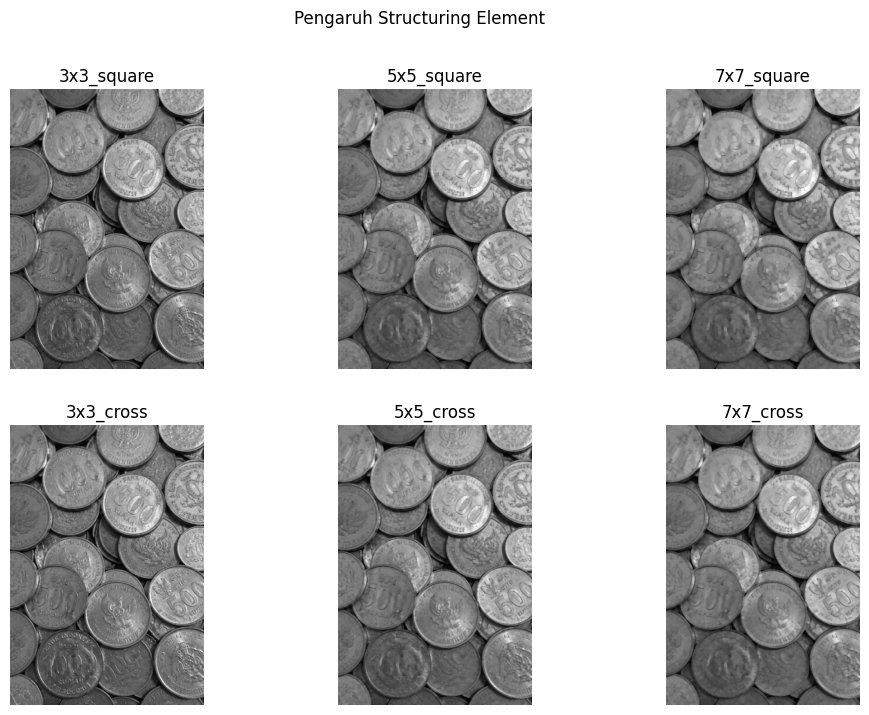

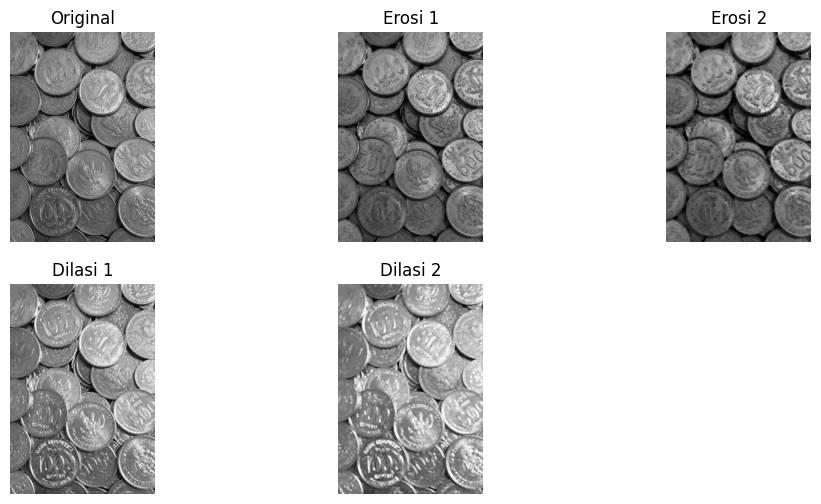

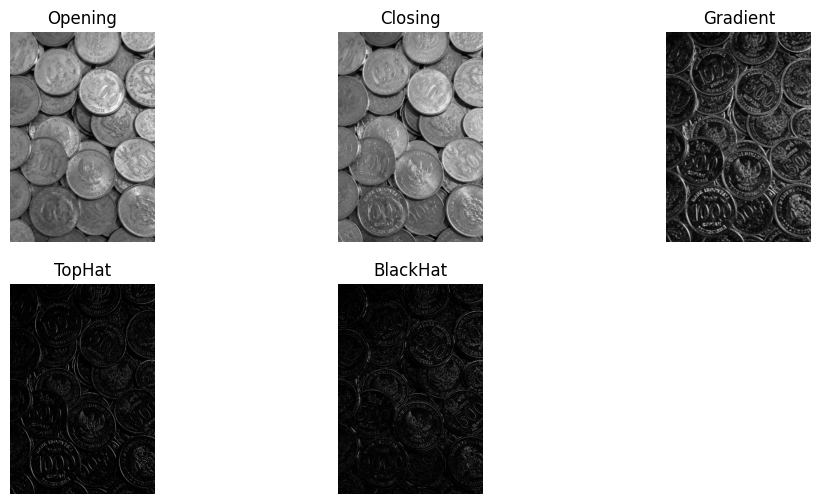

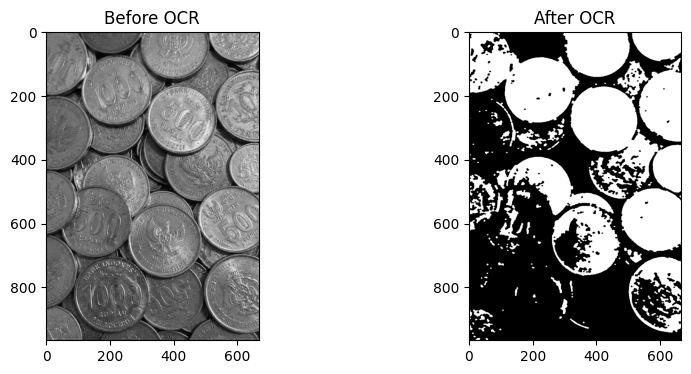

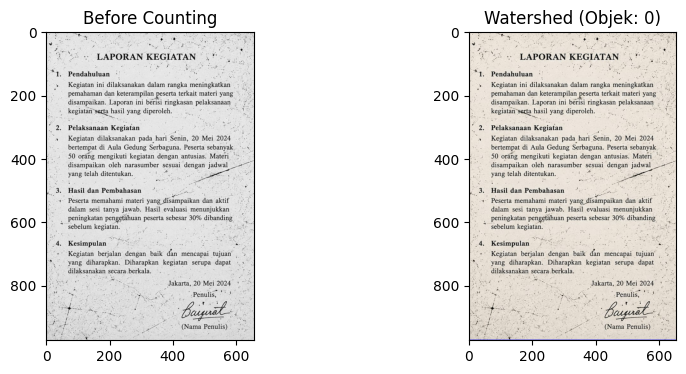

===== HASIL ANALISIS =====
Jumlah objek terdeteksi: 0
Waktu OCR: 0.0072 detik
Waktu Counting: 0.0442 detik

Analisis:
- Kernel kecil: detail terjaga, noise masih ada
- Kernel besar: noise hilang, bentuk bisa rusak
- Opening efektif untuk noise removal
- Closing efektif untuk menyambung objek
- Watershed paling akurat untuk objek menempel


In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import time

# =========================
# UPLOAD GAMBAR
# =========================
print("Upload 2 gambar:")
print("1. Citra A (teks OCR)")
print("2. Citra B (objek counting)")
uploaded = files.upload()

file_names = list(uploaded.keys())

if len(file_names) < 2:
    raise Exception("Upload minimal 2 gambar!")

imgA = cv2.imread(file_names[0])
imgB = cv2.imread(file_names[1])

grayA = cv2.cvtColor(imgA, cv2.COLOR_BGR2GRAY)
grayB = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)

# =========================
# STRUCTURING ELEMENT VARIASI
# =========================
kernels = {
    "3x3_square": cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)),
    "5x5_square": cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)),
    "7x7_square": cv2.getStructuringElement(cv2.MORPH_RECT, (7,7)),

    "3x3_cross": cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3)),
    "5x5_cross": cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5)),
    "7x7_cross": cv2.getStructuringElement(cv2.MORPH_CROSS, (7,7)),

    "3x3_ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)),
    "5x5_ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)),
    "7x7_ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
}

# =========================
# EKSPERIMEN EROSI & DILASI (ITERASI)
# =========================
kernel = kernels["5x5_ellipse"]

erosi1 = cv2.erode(grayA, kernel, iterations=1)
erosi2 = cv2.erode(grayA, kernel, iterations=2)

dilasi1 = cv2.dilate(grayA, kernel, iterations=1)
dilasi2 = cv2.dilate(grayA, kernel, iterations=2)

# =========================
# OPERASI MAJEMUK
# =========================
opening = cv2.morphologyEx(grayA, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(grayA, cv2.MORPH_CLOSE, kernel)

gradient = cv2.morphologyEx(grayA, cv2.MORPH_GRADIENT, kernel)
tophat = cv2.morphologyEx(grayA, cv2.MORPH_TOPHAT, kernel)
blackhat = cv2.morphologyEx(grayA, cv2.MORPH_BLACKHAT, kernel)

# =========================
# OCR PIPELINE
# =========================
start = time.time()

ocr_clean = cv2.morphologyEx(grayA, cv2.MORPH_OPEN, kernel)
ocr_clean = cv2.morphologyEx(ocr_clean, cv2.MORPH_CLOSE, kernel)
_, threshA = cv2.threshold(ocr_clean, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

ocr_time = time.time() - start

# =========================
# COUNTING OBJECT (WATERSHED)
# =========================
start = time.time()

_, threshB = cv2.threshold(grayB, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
openingB = cv2.morphologyEx(threshB, cv2.MORPH_OPEN, kernel, iterations=2)

dist = cv2.distanceTransform(openingB, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(openingB, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(imgB, markers)
imgB[markers == -1] = [255, 0, 0]

count_time = time.time() - start

# HITUNG OBJEK
num_objects = len(np.unique(markers)) - 2

# =========================
# VISUALISASI STRUCTURING ELEMENT EFFECT
# =========================
plt.figure(figsize=(12,8))
i = 1
for name, k in list(kernels.items())[:6]:
    result = cv2.morphologyEx(grayA, cv2.MORPH_OPEN, k)
    plt.subplot(2,3,i)
    plt.imshow(result, cmap='gray')
    plt.title(name)
    plt.axis('off')
    i += 1
plt.suptitle("Pengaruh Structuring Element")
plt.show()

# =========================
# VISUALISASI OPERASI DASAR
# =========================
plt.figure(figsize=(12,6))
titles = ['Original','Erosi 1','Erosi 2','Dilasi 1','Dilasi 2']
images = [grayA, erosi1, erosi2, dilasi1, dilasi2]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# =========================
# VISUALISASI MORFOLOGI
# =========================
plt.figure(figsize=(12,6))
titles = ['Opening','Closing','Gradient','TopHat','BlackHat']
images = [opening, closing, gradient, tophat, blackhat]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# =========================
# OCR RESULT
# =========================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(grayA, cmap='gray')
plt.title("Before OCR")

plt.subplot(1,2,2)
plt.imshow(threshA, cmap='gray')
plt.title("After OCR")

plt.show()

# =========================
# COUNTING RESULT
# =========================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(grayB, cmap='gray')
plt.title("Before Counting")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB))
plt.title(f"Watershed (Objek: {num_objects})")

plt.show()

# =========================
# OUTPUT ANALISIS
# =========================
print("===== HASIL ANALISIS =====")
print(f"Jumlah objek terdeteksi: {num_objects}")
print(f"Waktu OCR: {ocr_time:.4f} detik")
print(f"Waktu Counting: {count_time:.4f} detik")

print("\nAnalisis:")
print("- Kernel kecil: detail terjaga, noise masih ada")
print("- Kernel besar: noise hilang, bentuk bisa rusak")
print("- Opening efektif untuk noise removal")
print("- Closing efektif untuk menyambung objek")
print("- Watershed paling akurat untuk objek menempel")